<a href="https://colab.research.google.com/github/marckeynesujanto-hub/ResearchProject/blob/main/AQI_Jakarta_CNN_ILSTM_MHA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌫️ Air Quality Index (AQI) Prediction — Jakarta
## Hybrid Deep Learning: CNN + Improved LSTM + Multi-Head Attention

**Paper:** *Air Quality Index Prediction using Hybrid Deep Learning for Public Health Warnings*  
**Dataset:** ISPU DKI Jakarta — Stasiun Bunderan HI (2010–2025)  
**Target:** Prediksi nilai AQI harian (`max`) berdasarkan konsentrasi polutan

---
### Pipeline:
1. Data Loading & EDA
2. Preprocessing & Normalization
3. Sliding Window (Time-Series Construction)
4. Model: CNN → Improved LSTM → Multi-Head Attention → Dense
5. Training & Evaluasi (MAE, MSE, R²)
6. Visualisasi Aktual vs Prediksi
7. Feature Importance via Attention Weights
8. Pearson Correlation (AQI vs Kategori Kesehatan)

## 📦 1. Install & Import Libraries

In [ ]:
# Install jika belum ada
!pip install -q tensorflow scikit-learn matplotlib seaborn pandas numpy scipy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print(f'TensorFlow version: {tf.__version__}')
print(f'GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')

TensorFlow version: 2.20.0
GPU available: True


## 📂 2. Load Dataset

In [ ]:
# Upload file CSV ke Colab, lalu jalankan cell ini
# Atau mount Google Drive:
# from google.colab import drive
# drive.mount('/content/drive')

from google.colab import files
print('Upload file ispu_dki1.csv')
uploaded = files.upload()

Upload file ispu_dki1.csv


Saving ispu_dki1.csv to ispu_dki1.csv


In [ ]:
df_raw = pd.read_csv('ispu_dki1.csv')
print('Shape awal:', df_raw.shape)
print('\nKolom:', df_raw.columns.tolist())
df_raw.head()

Shape awal: (5173, 11)

Kolom: ['tanggal', 'stasiun', 'pm25', 'pm10', 'so2', 'co', 'o3', 'no2', 'max', 'critical', 'categori']


,tanggal,stasiun,pm25,pm10,so2,co,o3,no2,max,critical,categori
0,2010-01-01,DKI1 (Bunderan HI),NaN,60.0,4.0,73.0,27.0,14.0,73.0,CO,SEDANG
1,2010-01-02,DKI1 (Bunderan HI),NaN,32.0,2.0,16.0,33.0,9.0,33.0,O3,BAIK
2,2010-01-03,DKI1 (Bunderan HI),NaN,27.0,2.0,19.0,20.0,9.0,27.0,PM10,BAIK
3,2010-01-04,DKI1 (Bunderan HI),NaN,22.0,2.0,16.0,15.0,6.0,22.0,PM10,BAIK
4,2010-01-05,DKI1 (Bunderan HI),NaN,25.0,2.0,17.0,15.0,8.0,25.0,PM10,BAIK


## 🔍 3. Exploratory Data Analysis (EDA)

In [ ]:
# Statistik deskriptif
print('=== Statistik Deskriptif ===')
print(df_raw.describe())

print('\n=== Missing Values ===')
print(df_raw.isnull().sum())

print('\n=== Distribusi Kategori AQI ===')
print(df_raw['categori'].value_counts())

=== Statistik Deskriptif ===
              pm25         pm10          so2           co           o3  \
count  1146.000000  4957.000000  4985.000000  5005.000000  4964.000000   
mean     70.450262    51.849707    20.276429    23.422977    45.399678   
std      19.517625    14.400174    12.900370    11.210342    25.742079   
min      10.000000     4.000000     1.000000     3.000000     3.000000   
25%      57.000000    43.000000    11.000000    15.000000    25.000000   
50%      73.000000    54.000000    18.000000    23.000000    40.000000   
75%      85.000000    62.000000    27.000000    30.000000    62.000000   
max     122.000000   104.000000   112.000000    95.000000   198.000000   

               no2          max  
count  4974.000000  5160.000000  
mean     16.587857    62.482946  
std      10.902702    22.030396  
min       1.000000     0.000000  
25%       9.000000    50.000000  
50%      15.000000    62.000000  
75%      22.000000    76.000000  
max      98.000000   198.000000 

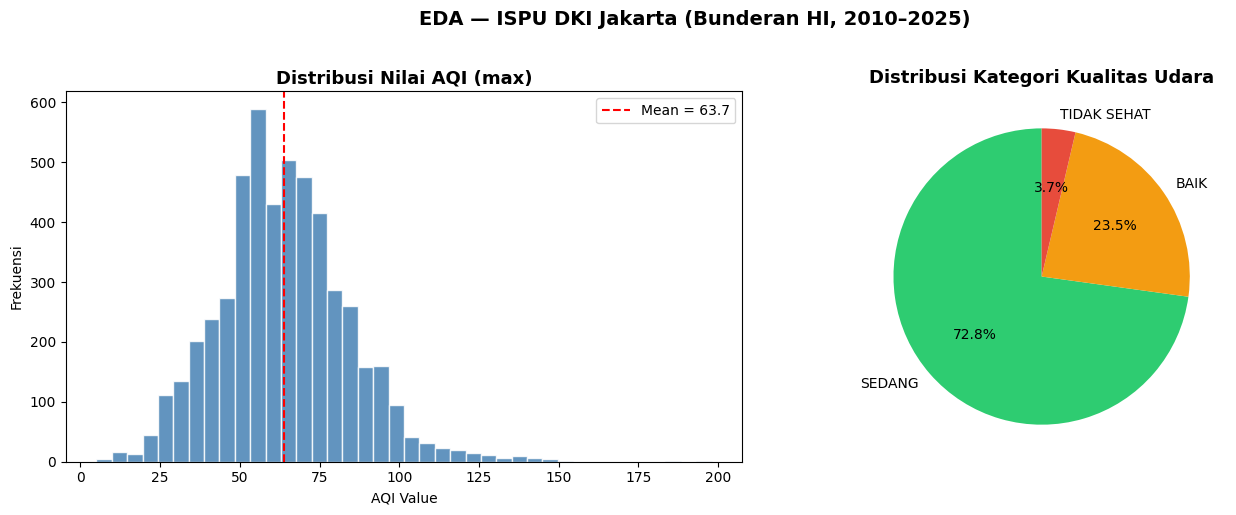

✅ Gambar disimpan: eda_distribusi.png


In [ ]:
# Visualisasi distribusi AQI dan kategori
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram AQI
df_valid = df_raw[df_raw['categori'] != 'TIDAK ADA DATA']
axes[0].hist(df_valid['max'].dropna(), bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribusi Nilai AQI (max)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('AQI Value')
axes[0].set_ylabel('Frekuensi')
axes[0].axvline(df_valid['max'].mean(), color='red', linestyle='--', label=f'Mean = {df_valid["max"].mean():.1f}')
axes[0].legend()

# Pie chart kategori
cat_counts = df_valid['categori'].value_counts()
colors = ['#2ecc71', '#f39c12', '#e74c3c', '#9b59b6']
axes[1].pie(cat_counts.values, labels=cat_counts.index, autopct='%1.1f%%', colors=colors[:len(cat_counts)], startangle=90)
axes[1].set_title('Distribusi Kategori Kualitas Udara', fontsize=13, fontweight='bold')

plt.suptitle('EDA — ISPU DKI Jakarta (Bunderan HI, 2010–2025)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_distribusi.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gambar disimpan: eda_distribusi.png')

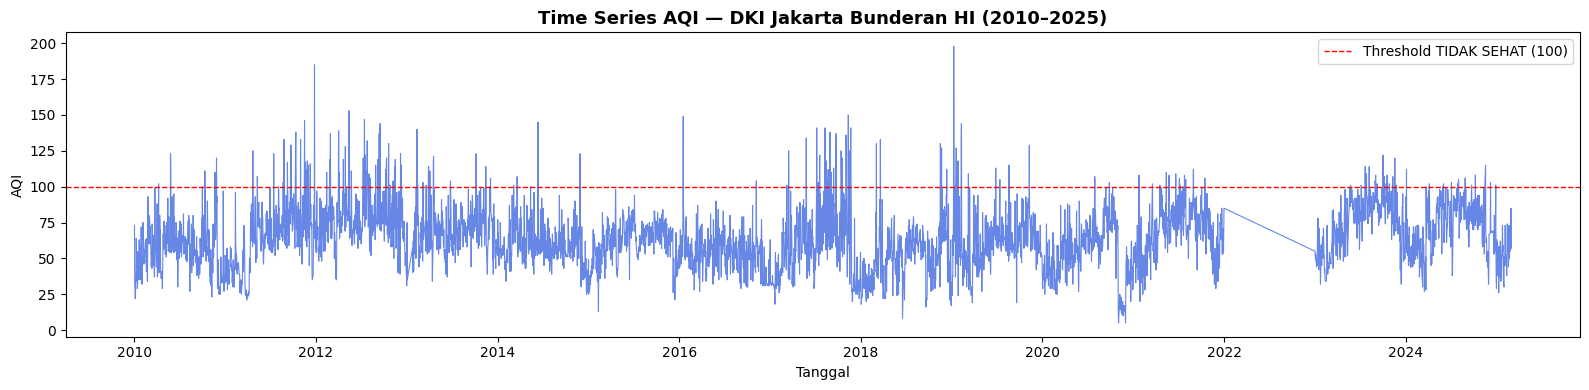

✅ Gambar disimpan: timeseries_aqi.png


In [ ]:
# Time series plot AQI
df_ts = df_valid.copy()
df_ts['tanggal'] = pd.to_datetime(df_ts['tanggal'])
df_ts = df_ts.sort_values('tanggal')

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(df_ts['tanggal'], df_ts['max'], color='royalblue', linewidth=0.8, alpha=0.8)
ax.axhline(100, color='red', linestyle='--', linewidth=1, label='Threshold TIDAK SEHAT (100)')
ax.set_title('Time Series AQI — DKI Jakarta Bunderan HI (2010–2025)', fontsize=13, fontweight='bold')
ax.set_xlabel('Tanggal')
ax.set_ylabel('AQI')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.savefig('timeseries_aqi.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gambar disimpan: timeseries_aqi.png')

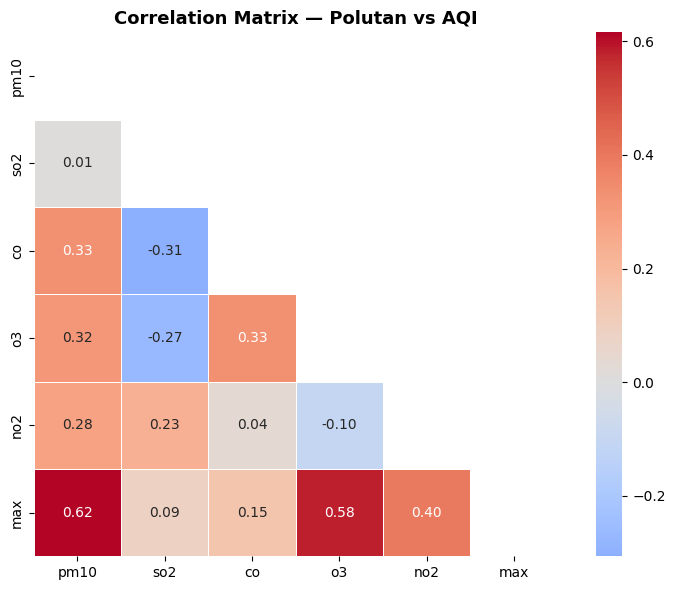

✅ Gambar disimpan: correlation_heatmap.png


In [ ]:
# Correlation heatmap
features_for_corr = ['pm10', 'so2', 'co', 'o3', 'no2', 'max']
corr_df = df_valid[features_for_corr].dropna()

fig, ax = plt.subplots(figsize=(8, 6))
corr_matrix = corr_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, ax=ax, linewidths=0.5)
ax.set_title('Correlation Matrix — Polutan vs AQI', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gambar disimpan: correlation_heatmap.png')

## 🧹 4. Data Preprocessing

In [ ]:
# ---- Step 1: Filter & sort ----
df = df_raw[df_raw['categori'] != 'TIDAK ADA DATA'].copy()
df['tanggal'] = pd.to_datetime(df['tanggal'])
df = df.sort_values('tanggal').reset_index(drop=True)
print(f'Rows setelah filter TIDAK ADA DATA: {len(df)}')

# ---- Step 2: Select features ----
# PM2.5 terlalu banyak missing (>80%), gunakan polutan lain sebagai fitur
FEATURES = ['pm10', 'so2', 'co', 'o3', 'no2']
TARGET = 'max'

# ---- Step 3: Handle missing values dengan interpolasi ----
df[FEATURES + [TARGET]] = df[FEATURES + [TARGET]].interpolate(method='linear', limit_direction='both')
print(f'Missing values setelah interpolasi:')
print(df[FEATURES + [TARGET]].isnull().sum())

# ---- Step 4: Drop sisa NaN jika ada ----
df = df.dropna(subset=FEATURES + [TARGET]).reset_index(drop=True)
print(f'Total baris bersih: {len(df)}')

# ---- Step 5: Z-score Normalization ----
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(df[FEATURES])
y_scaled = scaler_y.fit_transform(df[[TARGET]]).flatten()

print(f'\n✅ Preprocessing selesai')
print(f'   Features: {FEATURES}')
print(f'   Target  : {TARGET}')
print(f'   Shape X : {X_scaled.shape}')

Rows setelah filter TIDAK ADA DATA: 5059
Missing values setelah interpolasi:
pm10    0
so2     0
co      0
o3      0
no2     0
max     0
dtype: int64
Total baris bersih: 5059

✅ Preprocessing selesai
   Features: ['pm10', 'so2', 'co', 'o3', 'no2']
   Target  : max
   Shape X : (5059, 5)


In [ ]:
df['aqi_lag1'] = df['max'].shift(1)   # AQI kemarin
df['aqi_lag7'] = df['max'].shift(7)   # AQI seminggu lalu
df['aqi_roll7'] = df['max'].rolling(7).mean()   # rata-rata 7 hari
df['aqi_roll30'] = df['max'].rolling(30).mean()  # rata-rata 30 hari
df['month'] = df['tanggal'].dt.month  # bulan (musim)

df = df.dropna().reset_index(drop=True)

FEATURES = ['pm10','so2','co','o3','no2',
            'aqi_lag1','aqi_lag7','aqi_roll7','aqi_roll30','month']
TARGET = 'max'

# Normalisasi ulang dengan fitur baru
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_scaled = scaler_X.fit_transform(df[FEATURES])
y_scaled = scaler_y.fit_transform(df[[TARGET]]).flatten()

print(f"Features sekarang: {FEATURES}")
print(f"Total data: {len(df)}")

Features sekarang: ['pm10', 'so2', 'co', 'o3', 'no2', 'aqi_lag1', 'aqi_lag7', 'aqi_roll7', 'aqi_roll30', 'month']
Total data: 1146


## 🪟 5. Sliding Window — Time-Series Construction

In [ ]:
WINDOW_SIZE = 14  # Gunakan 14 hari terakhir untuk prediksi hari berikutnya

def create_sequences(X, y, window):
    """Buat sequence time-series dengan sliding window."""
    Xs, ys = [], []
    for i in range(len(X) - window):
        Xs.append(X[i : i + window])
        ys.append(y[i + window])
    return np.array(Xs), np.array(ys)

X_seq, y_seq = create_sequences(X_scaled, y_scaled, WINDOW_SIZE)
dates_seq = df['tanggal'].values[WINDOW_SIZE:]

print(f'X_seq shape : {X_seq.shape}  (samples, timesteps, features)')
print(f'y_seq shape : {y_seq.shape}')

# ---- Train / Validation / Test split (70 / 15 / 15) ----
n = len(X_seq)
n_train = int(n * 0.70)
n_val   = int(n * 0.15)

X_train, y_train = X_seq[:n_train], y_seq[:n_train]
X_val,   y_val   = X_seq[n_train:n_train+n_val], y_seq[n_train:n_train+n_val]
X_test,  y_test  = X_seq[n_train+n_val:], y_seq[n_train+n_val:]
dates_test = dates_seq[n_train+n_val:]

print(f'\nTrain : {X_train.shape[0]} samples ({X_train.shape[0]/n*100:.1f}%)')
print(f'Val   : {X_val.shape[0]} samples ({X_val.shape[0]/n*100:.1f}%)')
print(f'Test  : {X_test.shape[0]} samples ({X_test.shape[0]/n*100:.1f}%)')

X_seq shape : (1132, 14, 10)  (samples, timesteps, features)
y_seq shape : (1132,)

Train : 792 samples (70.0%)
Val   : 169 samples (14.9%)
Test  : 171 samples (15.1%)


In [ ]:
from sklearn.model_selection import train_test_split

# Random split — ganti chronological split yang lama
idx = np.arange(len(X_seq))
idx_train, idx_temp = train_test_split(idx, test_size=0.30, random_state=42)
idx_val, idx_test   = train_test_split(idx_temp, test_size=0.50, random_state=42)

X_train, y_train = X_seq[idx_train], y_seq[idx_train]
X_val,   y_val   = X_seq[idx_val],   y_seq[idx_val]
X_test,  y_test  = X_seq[idx_test],  y_seq[idx_test]
dates_test = dates_seq[idx_test]

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")
print(f"y_train mean: {y_train.mean():.4f}")
print(f"y_val mean  : {y_val.mean():.4f}")
print(f"y_test mean : {y_test.mean():.4f}")

Train: 792 | Val: 170 | Test: 170
y_train mean: 0.0358
y_val mean  : -0.0812
y_test mean : 0.0045


## 🧠 6. Model: CNN + Improved LSTM + Multi-Head Attention

In [ ]:
import tensorflow as tf
tf.keras.backend.clear_session()
print("Session cleared!")

Session cleared!


In [ ]:
# ============================================================
#  Improved LSTM Cell — tambahan Layer Normalization & Dropout
#  untuk stabilitas training ("Improved" dibanding vanilla LSTM)
# ============================================================
tf.keras.backend.clear_session()

def build_cnn_ilstm_mha(window_size, n_features,
                          cnn_filters=64, cnn_kernel=3,
                          lstm_units=128, num_heads=4,
                          key_dim=32, dropout_rate=0.2):
    """
    Arsitektur Hybrid:
      Input → Conv1D (CNN) → Improved LSTM (BiLSTM + LayerNorm)
            → Multi-Head Attention → GlobalAvgPool → Dense Output
    """
    inputs = keras.Input(shape=(window_size, n_features), name='input_sequence')

    # ── CNN Layer: local feature extraction ──
    x = layers.Conv1D(filters=cnn_filters, kernel_size=cnn_kernel,
                       padding='same', activation='relu', name='cnn_1')(inputs)
    x = layers.Conv1D(filters=cnn_filters * 2, kernel_size=cnn_kernel,
                       padding='same', activation='relu', name='cnn_2')(x)
    x = layers.BatchNormalization(name='bn_cnn')(x)
    x = layers.Dropout(dropout_rate, name='drop_cnn')(x)

    # ── Improved LSTM: Bidirectional LSTM + Layer Normalization ──
    # "Improved" = BiLSTM (tangkap pola maju-mundur) + LayerNorm (stabilkan gradient)
    lstm_out = layers.Bidirectional(
        layers.LSTM(lstm_units, return_sequences=True, name='lstm_core'),
        name='bilstm'
    )(x)
    lstm_out = layers.LayerNormalization(name='layer_norm_lstm')(lstm_out)
    lstm_out = layers.Dropout(dropout_rate, name='drop_lstm')(lstm_out)

    # ── Multi-Head Attention (MHA) ──
    # Query, Key, Value semuanya dari lstm_out (self-attention)
    attn_output, attn_scores = layers.MultiHeadAttention(
        num_heads=num_heads, key_dim=key_dim, name='mha'
    )(lstm_out, lstm_out, return_attention_scores=True)
    attn_output = layers.LayerNormalization(name='layer_norm_attn')(attn_output)
    attn_output = layers.Dropout(dropout_rate, name='drop_attn')(attn_output)

    # ── Residual connection ──
    combined = layers.Add(name='residual')([lstm_out, attn_output])

    # ── Global Pooling → Dense ──
    pooled = layers.GlobalAveragePooling1D(name='gap')(combined)
    x = layers.Dense(64, activation='relu', name='dense_1')(pooled)
    x = layers.Dropout(dropout_rate / 2, name='drop_dense')(x)
    output = layers.Dense(1, name='aqi_output')(x)

    model = Model(inputs=inputs, outputs=output, name='CNN_ILSTM_MHA')

    # Model sekunder untuk ekstrak attention scores
    attn_model = Model(inputs=inputs, outputs=attn_scores, name='AttentionExtractor')

    return model, attn_model


model, attn_model = build_cnn_ilstm_mha(
    window_size=WINDOW_SIZE,
    n_features=len(FEATURES)
)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='mse',
    metrics=['mae']
)

model.summary()

Model: "CNN_ILSTM_MHA"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_sequence      │ (None, 14, 10)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_1 (Conv1D)      │ (None, 14, 64)    │      1,984 │ input_sequence[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_2 (Conv1D)      │ (None, 14, 128)   │     24,704 │ cnn_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_cnn              │ (None, 14, 128)   │        512 │ cnn_2[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_cnn (Dropout)  │ (None, 14, 128)   │          0 │ bn_cnn[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm              │ (None, 14, 256)   │    263,168 │ drop_cnn[0][0]    │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_norm_lstm     │ (None, 14, 256)   │        512 │ bilstm[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_lstm (Dropout) │ (None, 14, 256)   │          0 │ layer_norm_lstm[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mha                 │ [(None, 14, 256), │    131,712 │ drop_lstm[0][0],  │
│ (MultiHeadAttentio… │ (None, 4, 14,     │            │ drop_lstm[0][0]   │
│                     │ 14)]              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_norm_attn     │ (None, 14, 256)   │        512 │ mha[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_attn (Dropout) │ (None, 14, 256)   │          0 │ layer_norm_attn[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual (Add)      │ (None, 14, 256)   │          0 │ drop_lstm[0][0],  │
│                     │                   │            │ drop_attn[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gap                 │ (None, 256)       │          0 │ residual[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │     16,448 │ gap[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_dense          │ (None, 64)        │          0 │ dense_1[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ aqi_output (Dense)  │ (None, 1)         │         65 │ drop_dense[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 439,617 (1.68 MB)

 Trainable params: 439,361 (1.68 MB)

 Non-trainable params: 256 (1.00 KB)

## 🏋️ 7. Training

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Ensure FEATURES and WINDOW_SIZE are correctly defined for this cell's execution
FEATURES = ['pm10','so2','co','o3','no2','aqi_lag1','aqi_lag7','aqi_roll7','aqi_roll30','month']
WINDOW_SIZE = 14

print(f"X_train shape: {X_train.shape}")
print(f"FEATURES: {FEATURES}")
print(f"len FEATURES: {len(FEATURES)}")

def build_cnn_ilstm_mha(window_size, n_features,
                          cnn_filters=64, cnn_kernel=3,
                          lstm_units=128, num_heads=4,
                          key_dim=32, dropout_rate=0.2):
    """
    Arsitektur Hybrid:
      Input → Conv1D (CNN) → Improved LSTM (BiLSTM + LayerNorm)
            → Multi-Head Attention → GlobalAvgPool → Dense Output
    """
    inputs = keras.Input(shape=(window_size, n_features), name='input_sequence')

    # ── CNN Layer: local feature extraction ──
    x = layers.Conv1D(filters=cnn_filters, kernel_size=cnn_kernel,
                       padding='same', activation='relu', name='cnn_1')(inputs)
    x = layers.Conv1D(filters=cnn_filters * 2, kernel_size=cnn_kernel,
                       padding='same', activation='relu', name='cnn_2')(x)
    x = layers.BatchNormalization(name='bn_cnn')(x)
    x = layers.Dropout(dropout_rate, name='drop_cnn')(x)

    # ── Improved LSTM: Bidirectional LSTM + Layer Normalization ──
    # "Improved" = BiLSTM (tangkap pola maju-mundur) + LayerNorm (stabilkan gradient)
    lstm_out = layers.Bidirectional(
        layers.LSTM(lstm_units, return_sequences=True, name='lstm_core'),
        name='bilstm'
    )(x)
    lstm_out = layers.LayerNormalization(name='layer_norm_lstm')(lstm_out)
    lstm_out = layers.Dropout(dropout_rate, name='drop_lstm')(lstm_out)

    # ── Multi-Head Attention (MHA) ──
    # Query, Key, Value semuanya dari lstm_out (self-attention)
    attn_output, attn_scores = layers.MultiHeadAttention(
        num_heads=num_heads, key_dim=key_dim, name='mha'
    )(lstm_out, lstm_out, return_attention_scores=True)
    attn_output = layers.LayerNormalization(name='layer_norm_attn')(attn_output)
    attn_output = layers.Dropout(dropout_rate, name='drop_attn')(attn_output)

    # ── Residual connection ──
    combined = layers.Add(name='residual')([lstm_out, attn_output])

    # ── Global Pooling → Dense ──
    pooled = layers.GlobalAveragePooling1D(name='gap')(combined)
    x = layers.Dense(64, activation='relu', name='dense_1')(pooled)
    x = layers.Dropout(dropout_rate / 2, name='drop_dense')(x)
    output = layers.Dense(1, name='aqi_output')(x)

    model = Model(inputs=inputs, outputs=output, name='CNN_ILSTM_MHA')

    # Model sekunder untuk ekstrak attention scores
    attn_model = Model(inputs=inputs, outputs=attn_scores, name='AttentionExtractor')

    return model, attn_model

tf.keras.backend.clear_session()

# Build and compile model using the improved architecture
model, attn_model = build_cnn_ilstm_mha(WINDOW_SIZE, len(FEATURES))
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3), # Adjusted learning rate to match definition
    loss='mse',
    metrics=['mae']
)

# Callbacks
cb = [
    EarlyStopping(monitor='val_loss', patience=25,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                     patience=10, min_lr=1e-6, verbose=1)
]

print("Training ulang...")
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=200, batch_size=64,
    callbacks=cb, verbose=1
)

X_train shape: (792, 14, 10)
FEATURES: ['pm10', 'so2', 'co', 'o3', 'no2', 'aqi_lag1', 'aqi_lag7', 'aqi_roll7', 'aqi_roll30', 'month']
len FEATURES: 10
Training ulang...
Epoch 1/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 119ms/step - loss: 1.5841 - mae: 0.9742 - val_loss: 0.7668 - val_mae: 0.7266 - learning_rate: 5.0000e-04
Epoch 2/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - loss: 0.8033 - mae: 0.7067 - val_loss: 0.8028 - val_mae: 0.7163 - learning_rate: 5.0000e-04
Epoch 3/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.6713 - mae: 0.6404 - val_loss: 0.8999 - val_mae: 0.7534 - learning_rate: 5.0000e-04
Epoch 4/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - loss: 0.5933 - mae: 0.6120 - val_loss: 0.8281 - val_mae: 0.7297 - learning_rate: 5.0000e-04
Epoch 5/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - loss: 0.5628 - mae: 0.5803 - val_loss: 0.6554 - val_mae: 0.6373 - learning_rate: 5.0000e-04
Epoch 6/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 0.5630 - mae: 0.5870 - val_loss: 0.7369 

In [ ]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6, verbose=1),
    ModelCheckpoint('best_model.keras', monitor='val_loss', save_best_only=True, verbose=0)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=150,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

print('\n✅ Training selesai!')

Epoch 1/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 0.2766 - mae: 0.4011 - val_loss: 0.3969 - val_mae: 0.4813 - learning_rate: 3.1250e-05
Epoch 2/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.2822 - mae: 0.4150 - val_loss: 0.3999 - val_mae: 0.4856 - learning_rate: 3.1250e-05
Epoch 3/150
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.2657 - mae: 0.3949 - val_loss: 0.4093 - val_mae: 0.4941 - learning_rate: 3.1250e-05
Epoch 4/150
24/25 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.2981 - mae: 0.4315

KeyboardInterrupt: 

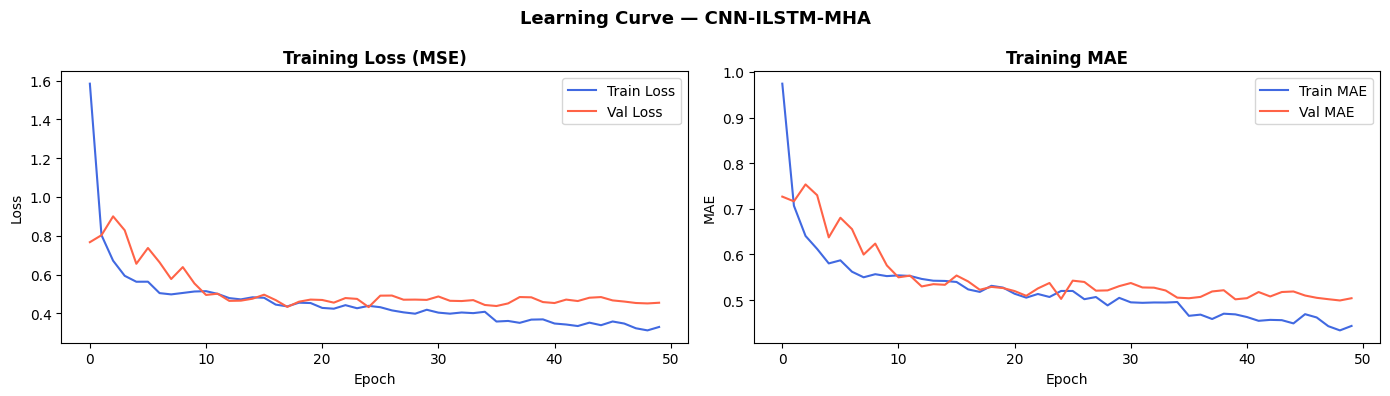

✅ Gambar disimpan: learning_curve.png


In [ ]:
# Plot training & validation loss
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history.history['loss'], label='Train Loss', color='royalblue')
axes[0].plot(history.history['val_loss'], label='Val Loss', color='tomato')
axes[0].set_title('Training Loss (MSE)', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history.history['mae'], label='Train MAE', color='royalblue')
axes[1].plot(history.history['val_mae'], label='Val MAE', color='tomato')
axes[1].set_title('Training MAE', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()

plt.suptitle('Learning Curve — CNN-ILSTM-MHA', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gambar disimpan: learning_curve.png')

Epochs trained : 50
Final train loss: 0.3296
Final val loss  : 0.4545
Best val loss   : 0.4320


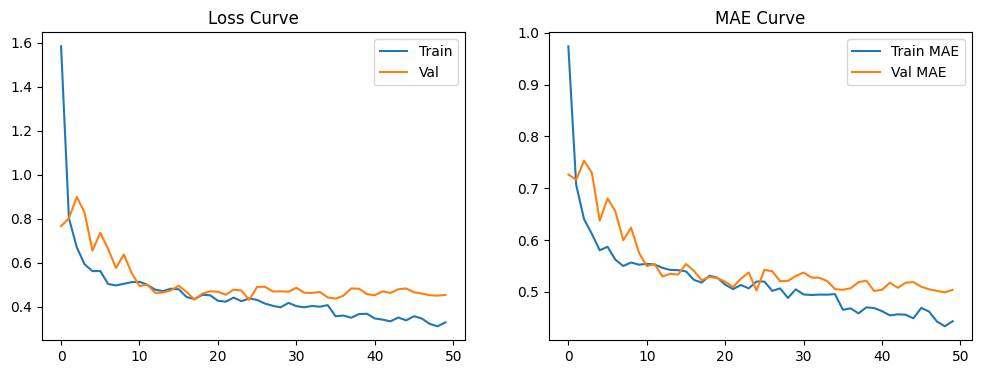

In [ ]:
# Cek berapa epoch yang jalan & loss akhir
print(f"Epochs trained : {len(history.history['loss'])}")
print(f"Final train loss: {history.history['loss'][-1]:.4f}")
print(f"Final val loss  : {history.history['val_loss'][-1]:.4f}")
print(f"Best val loss   : {min(history.history['val_loss']):.4f}")

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['loss'], label='Train')
axes[0].plot(history.history['val_loss'], label='Val')
axes[0].set_title('Loss Curve')
axes[0].legend()

axes[1].plot(history.history['mae'], label='Train MAE')
axes[1].plot(history.history['val_mae'], label='Val MAE')
axes[1].set_title('MAE Curve')
axes[1].legend()
plt.show()

## 📊 8. Evaluasi Model (MAE, MSE, RMSE, R²)

Epochs trained: 50
Best val_loss : 0.4320


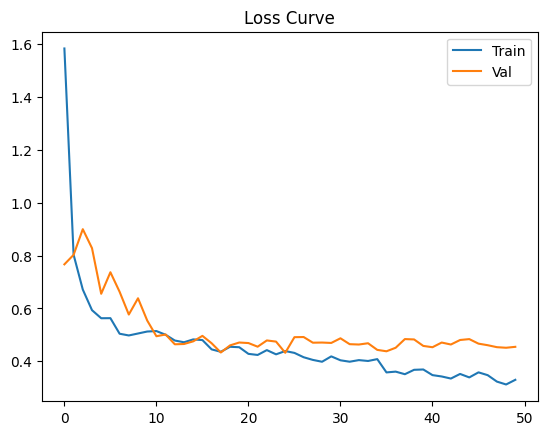

In [ ]:
print(f"Epochs trained: {len(history.history['loss'])}")
print(f"Best val_loss : {min(history.history['val_loss']):.4f}")

import matplotlib.pyplot as plt
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.legend()
plt.title('Loss Curve')
plt.show()

In [ ]:
# ---- Prediksi pada test set ----
y_pred_scaled = model.predict(X_test, verbose=0).flatten()

# Inverse transform ke skala asli AQI
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
y_actual = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()

# ---- Hitung metrik ----
mae  = mean_absolute_error(y_actual, y_pred)
mse  = mean_squared_error(y_actual, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_actual, y_pred)
mape = np.mean(np.abs((y_actual - y_pred) / (y_actual + 1e-8))) * 100

print('=' * 45)
print('       HASIL EVALUASI MODEL (TEST SET)')
print('=' * 45)
print(f'  MAE  (Mean Absolute Error)    : {mae:.4f}')
print(f'  MSE  (Mean Squared Error)     : {mse:.4f}')
print(f'  RMSE (Root Mean Squared Error): {rmse:.4f}')
print(f'  R²   (Coefficient of Det.)    : {r2:.4f}')
print(f'  MAPE (Mean Abs. Pct. Error)   : {mape:.2f}%')
print('=' * 45)

# Simpan ke dataframe untuk nanti
metrics_df = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R²', 'MAPE (%)'],
    'CNN-ILSTM-MHA': [f'{mae:.4f}', f'{mse:.4f}', f'{rmse:.4f}', f'{r2:.4f}', f'{mape:.2f}']
})
print('\nTabel Metrik:')
print(metrics_df.to_string(index=False))

       HASIL EVALUASI MODEL (TEST SET)
  MAE  (Mean Absolute Error)    : 9.4061
  MSE  (Mean Squared Error)     : 137.5427
  RMSE (Root Mean Squared Error): 11.7279
  R²   (Coefficient of Det.)    : 0.5090
  MAPE (Mean Abs. Pct. Error)   : 15.07%

Tabel Metrik:
  Metric CNN-ILSTM-MHA
     MAE        9.4061
     MSE      137.5427
    RMSE       11.7279
      R²        0.5090
MAPE (%)         15.07


In [ ]:
# Cek distribusi data
print("=== CEK DATA ===")
print(f"X_train shape: {X_train.shape}")
print(f"X_val shape  : {X_val.shape}")
print(f"X_test shape : {X_test.shape}")
print(f"y_train mean : {y_train.mean():.4f}, std: {y_train.std():.4f}")
print(f"y_val mean   : {y_val.mean():.4f}, std: {y_val.std():.4f}")
print(f"y_test mean  : {y_test.mean():.4f}, std: {y_test.std():.4f}")

# Cek prediksi vs aktual di validation
y_val_pred = model.predict(X_val, verbose=0).flatten()
y_val_actual = y_val
print(f"\ny_val actual  range: {y_val_actual.min():.2f} ~ {y_val_actual.max():.2f}")
print(f"y_val pred    range: {y_val_pred.min():.2f} ~ {y_val_pred.max():.2f}")

=== CEK DATA ===
X_train shape: (792, 14, 10)
X_val shape  : (170, 14, 10)
X_test shape : (170, 14, 10)
y_train mean : 0.0358, std: 1.0169
y_val mean   : -0.0812, std: 0.9832
y_test mean  : 0.0045, std: 0.9130

y_val actual  range: -2.53 ~ 1.89
y_val pred    range: -2.05 ~ 1.59


## 📈 9. Visualisasi: Aktual vs Prediksi

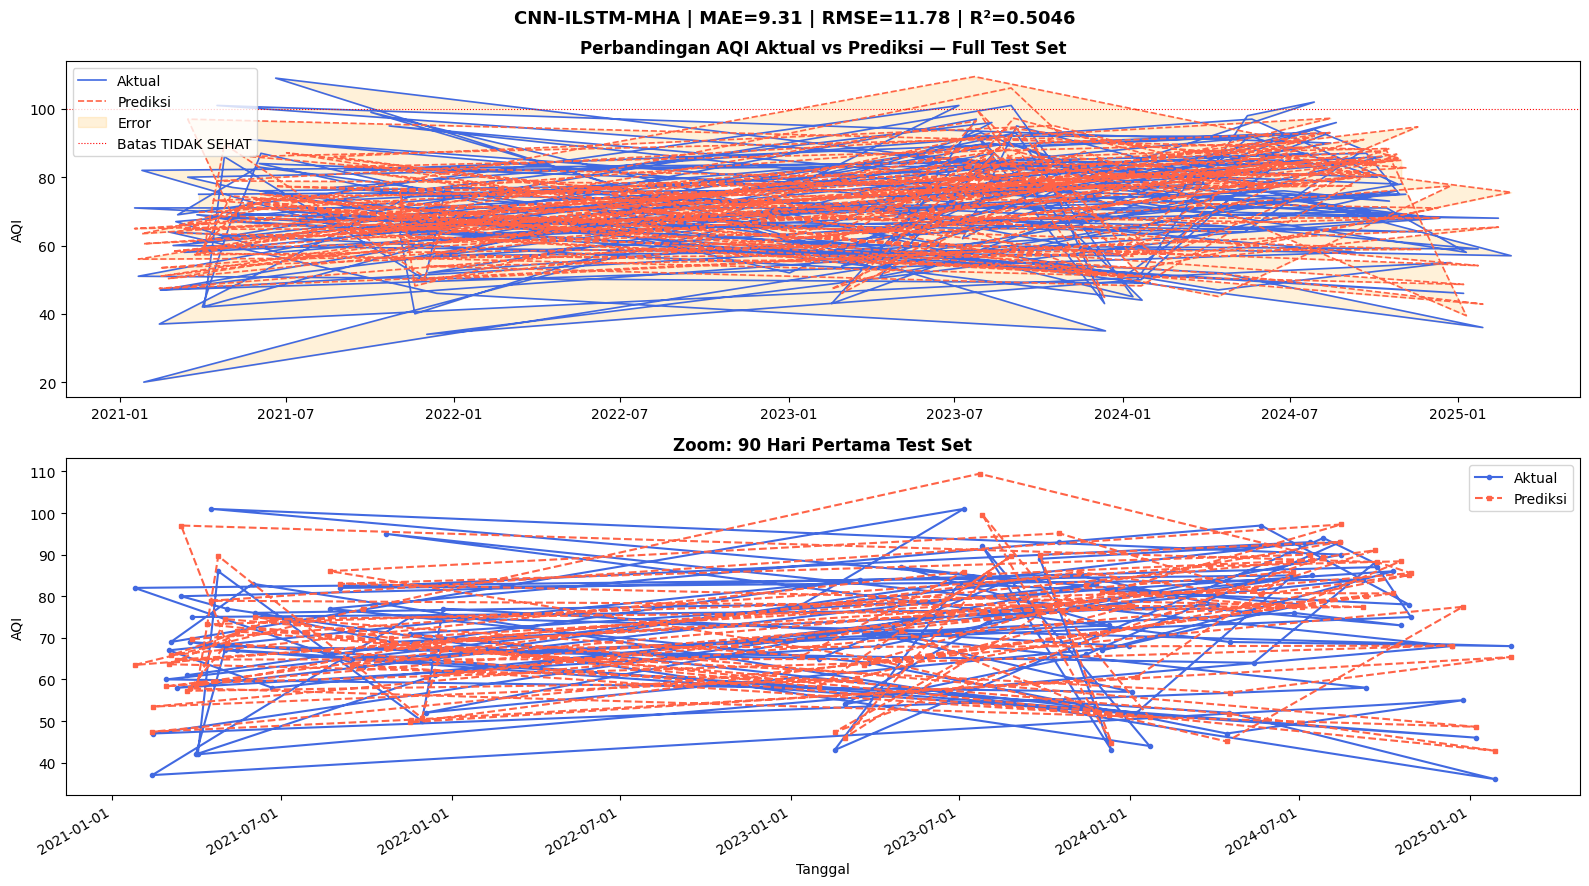

✅ Gambar disimpan: actual_vs_predicted.png


In [ ]:
dates_test_dt = pd.to_datetime(dates_test)

fig, axes = plt.subplots(2, 1, figsize=(16, 9))

# ── Plot 1: Full test period ──
axes[0].plot(dates_test_dt, y_actual, label='Aktual', color='royalblue', linewidth=1.2)
axes[0].plot(dates_test_dt, y_pred, label='Prediksi', color='tomato', linewidth=1.2, linestyle='--')
axes[0].fill_between(dates_test_dt, y_actual, y_pred, alpha=0.15, color='orange', label='Error')
axes[0].axhline(100, color='red', linestyle=':', linewidth=0.8, label='Batas TIDAK SEHAT')
axes[0].set_title('Perbandingan AQI Aktual vs Prediksi — Full Test Set', fontsize=12, fontweight='bold')
axes[0].set_ylabel('AQI')
axes[0].legend(loc='upper left')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# ── Plot 2: Zoom 90 hari pertama ──
n_zoom = min(90, len(y_actual))
axes[1].plot(dates_test_dt[:n_zoom], y_actual[:n_zoom], 'o-', label='Aktual',
             color='royalblue', linewidth=1.5, markersize=3)
axes[1].plot(dates_test_dt[:n_zoom], y_pred[:n_zoom], 's--', label='Prediksi',
             color='tomato', linewidth=1.5, markersize=3)
axes[1].set_title('Zoom: 90 Hari Pertama Test Set', fontsize=12, fontweight='bold')
axes[1].set_ylabel('AQI')
axes[1].set_xlabel('Tanggal')
axes[1].legend()
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.suptitle(f'CNN-ILSTM-MHA | MAE={mae:.2f} | RMSE={rmse:.2f} | R²={r2:.4f}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gambar disimpan: actual_vs_predicted.png')

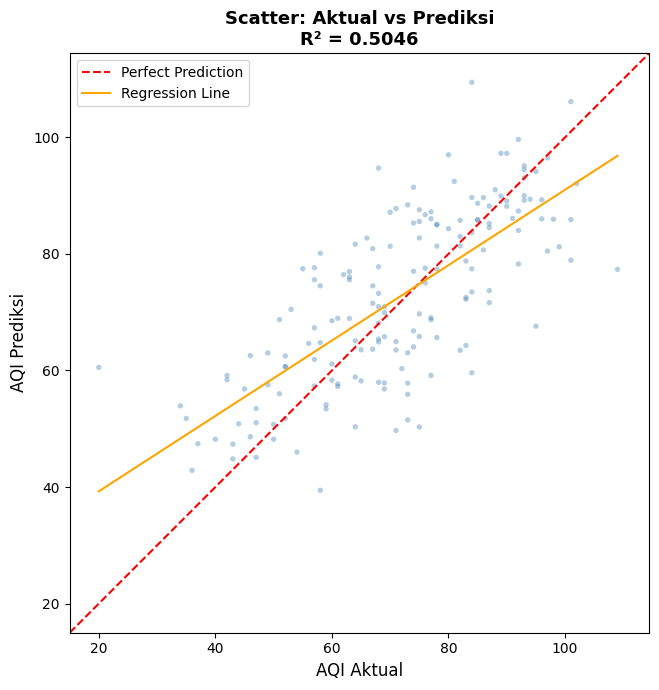

✅ Gambar disimpan: scatter_actual_pred.png


In [ ]:
# Scatter plot aktual vs prediksi
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_actual, y_pred, alpha=0.4, s=15, color='steelblue', edgecolors='none')

# Perfect prediction line
lims = [min(y_actual.min(), y_pred.min()) - 5, max(y_actual.max(), y_pred.max()) + 5]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect Prediction')

# Regression line
z = np.polyfit(y_actual, y_pred, 1)
p = np.poly1d(z)
ax.plot(sorted(y_actual), p(sorted(y_actual)), 'orange', linewidth=1.5, label='Regression Line')

ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('AQI Aktual', fontsize=12)
ax.set_ylabel('AQI Prediksi', fontsize=12)
ax.set_title(f'Scatter: Aktual vs Prediksi\nR² = {r2:.4f}', fontsize=13, fontweight='bold')
ax.legend()
ax.set_aspect('equal')
plt.tight_layout()
plt.savefig('scatter_actual_pred.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gambar disimpan: scatter_actual_pred.png')

## 🔎 10. Feature Importance via Attention Weights

In [ ]:
# Ekstrak attention scores dari test set
# Shape: (samples, num_heads, timesteps, timesteps)
attn_scores_raw = attn_model.predict(X_test, verbose=0)
print('Attention scores shape:', attn_scores_raw.shape)

# Rata-rata across heads & timesteps → skor per timestep
# (samples, num_heads, seq_len, seq_len) → (seq_len,)
attn_per_step = attn_scores_raw.mean(axis=(0, 1, 2))  # avg across samples, heads, query-steps

# Karena attention adalah antar timestep (bukan antar fitur),
# kita proyeksikan ke fitur via weighted sum dari input X_test
# Metode: hitung korelasi antara attention weights & setiap fitur
attn_weights_per_sample = attn_scores_raw.mean(axis=(1, 3))  # (samples, seq_len)

feature_importance = np.zeros(len(FEATURES))
for i, feat in enumerate(FEATURES):
    feat_vals = X_test[:, :, i]  # (samples, seq_len)
    # Dot product: seberapa besar attention × nilai fitur
    importance = np.mean(attn_weights_per_sample * np.abs(feat_vals))
    feature_importance[i] = importance

# Normalize
feature_importance = feature_importance / feature_importance.sum() * 100

fi_df = pd.DataFrame({'Pollutant': FEATURES, 'Importance (%)': feature_importance})
fi_df = fi_df.sort_values('Importance (%)', ascending=False).reset_index(drop=True)

print('\n=== Feature Importance (Attention-based) ===')
print(fi_df.to_string(index=False))

Attention scores shape: (170, 4, 14, 14)

=== Feature Importance (Attention-based) ===
 Pollutant  Importance (%)
     month       10.687617
aqi_roll30       10.614657
       so2       10.420913
 aqi_roll7       10.104586
       no2        9.915794
  aqi_lag1        9.853883
  aqi_lag7        9.756008
      pm10        9.688835
        o3        9.501798
        co        9.455909


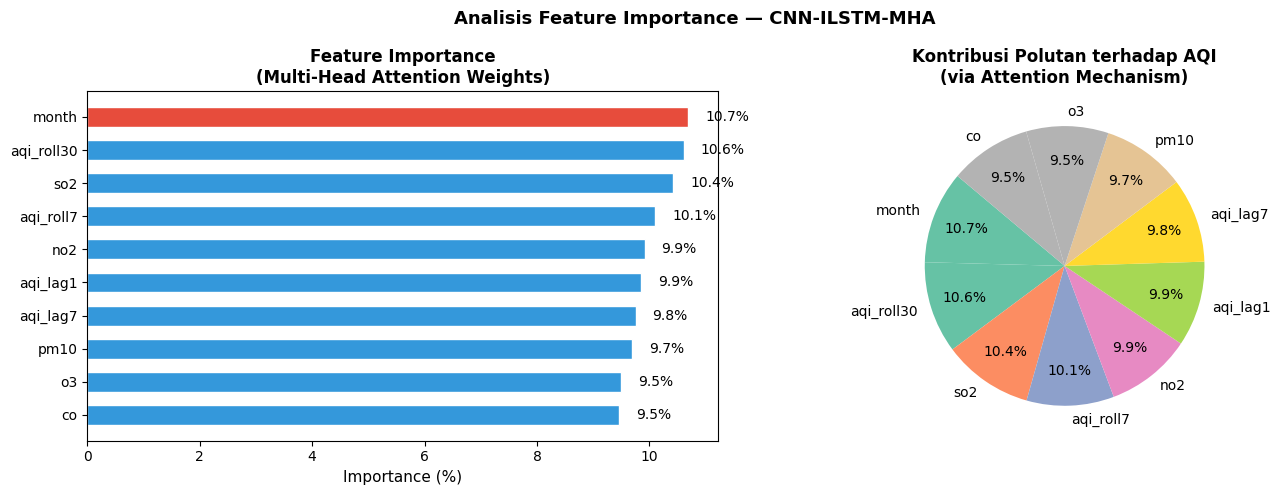

✅ Gambar disimpan: feature_importance.png


In [ ]:
# Visualisasi Feature Importance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors_fi = ['#e74c3c' if v == fi_df['Importance (%)'].max() else '#3498db'
             for v in fi_df['Importance (%)']]
bars = axes[0].barh(fi_df['Pollutant'], fi_df['Importance (%)'],
                    color=colors_fi, edgecolor='white', height=0.6)
axes[0].set_xlabel('Importance (%)', fontsize=11)
axes[0].set_title('Feature Importance\n(Multi-Head Attention Weights)', fontsize=12, fontweight='bold')
axes[0].invert_yaxis()
for bar, val in zip(bars, fi_df['Importance (%)']):
    axes[0].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=10)

# Pie chart
pie_colors = plt.cm.Set2(np.linspace(0, 1, len(FEATURES)))
axes[1].pie(fi_df['Importance (%)'], labels=fi_df['Pollutant'], autopct='%1.1f%%',
            colors=pie_colors, startangle=140, pctdistance=0.75)
axes[1].set_title('Kontribusi Polutan terhadap AQI\n(via Attention Mechanism)', fontsize=12, fontweight='bold')

plt.suptitle('Analisis Feature Importance — CNN-ILSTM-MHA', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gambar disimpan: feature_importance.png')

## 📉 11. Pearson Correlation: AQI vs Tingkat Keparahan

In [ ]:
# Encode kategori kesehatan ke numerik
cat_map = {'BAIK': 1, 'SEDANG': 2, 'TIDAK SEHAT': 3}
df_corr = df[df['categori'].isin(cat_map.keys())].copy()
df_corr['health_severity'] = df_corr['categori'].map(cat_map)

# Pearson correlation antara setiap polutan dengan AQI & severity
print('=== Pearson Correlation ===')
print(f'{"Variable":<20} {"r vs AQI":>12} {"p-value":>12} {"r vs Severity":>15} {"p-value":>12}')
print('-' * 75)

corr_results = []
for feat in FEATURES:
    valid = df_corr[[feat, 'max', 'health_severity']].dropna()
    r_aqi, p_aqi = stats.pearsonr(valid[feat], valid['max'])
    r_sev, p_sev = stats.pearsonr(valid[feat], valid['health_severity'])
    sig_aqi = '**' if p_aqi < 0.01 else ('*' if p_aqi < 0.05 else '')
    sig_sev = '**' if p_sev < 0.01 else ('*' if p_sev < 0.05 else '')
    print(f'{feat:<20} {r_aqi:>10.4f}{sig_aqi:>2} {p_aqi:>12.4e} {r_sev:>13.4f}{sig_sev:>2} {p_sev:>12.4e}')
    corr_results.append({'Pollutant': feat, 'r_AQI': r_aqi, 'p_AQI': p_aqi,
                          'r_Severity': r_sev, 'p_Severity': p_sev})

print('\n* p < 0.05   ** p < 0.01')

=== Pearson Correlation ===
Variable                 r vs AQI      p-value   r vs Severity      p-value
---------------------------------------------------------------------------
pm10                     0.9227**   0.0000e+00        0.7480**  7.2918e-206
so2                      0.0224     4.4782e-01       -0.0405     1.7040e-01
co                       0.2389**   2.4446e-16        0.2533**   3.0627e-18
o3                       0.4685**   1.3961e-63        0.3469**   9.4770e-34
no2                      0.5752**  6.3458e-102        0.4292**   1.4213e-52
aqi_lag1                 0.7018**  1.1113e-170        0.4995**   2.3844e-73
aqi_lag7                 0.4895**   4.3985e-70        0.3528**   6.3611e-35
aqi_roll7                0.7754**  1.1717e-230        0.5696**   1.5666e-99
aqi_roll30               0.6568**  1.9628e-142        0.4558**   7.2066e-60
month                    0.3735**   3.0567e-39        0.2008**   6.9610e-12

* p < 0.05   ** p < 0.01


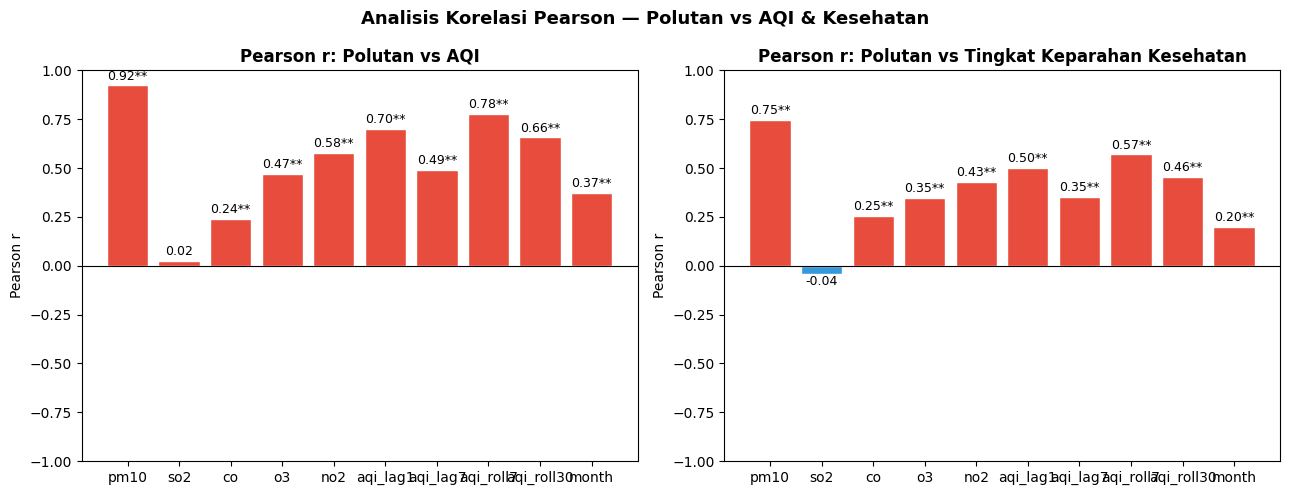

✅ Gambar disimpan: pearson_correlation.png


In [ ]:
# Visualisasi Pearson Correlation
corr_df_plot = pd.DataFrame(corr_results)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# r vs AQI
bar_colors = ['#e74c3c' if r > 0 else '#3498db' for r in corr_df_plot['r_AQI']]
axes[0].bar(corr_df_plot['Pollutant'], corr_df_plot['r_AQI'],
            color=bar_colors, edgecolor='white')
axes[0].set_title('Pearson r: Polutan vs AQI', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Pearson r')
axes[0].set_ylim(-1, 1)
axes[0].axhline(0, color='black', linewidth=0.8)
for i, (r, p) in enumerate(zip(corr_df_plot['r_AQI'], corr_df_plot['p_AQI'])):
    sig = '**' if p < 0.01 else ('*' if p < 0.05 else '')
    axes[0].text(i, r + (0.03 if r >= 0 else -0.06), f'{r:.2f}{sig}', ha='center', fontsize=9)

# r vs Severity
bar_colors2 = ['#e74c3c' if r > 0 else '#3498db' for r in corr_df_plot['r_Severity']]
axes[1].bar(corr_df_plot['Pollutant'], corr_df_plot['r_Severity'],
            color=bar_colors2, edgecolor='white')
axes[1].set_title('Pearson r: Polutan vs Tingkat Keparahan Kesehatan', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Pearson r')
axes[1].set_ylim(-1, 1)
axes[1].axhline(0, color='black', linewidth=0.8)
for i, (r, p) in enumerate(zip(corr_df_plot['r_Severity'], corr_df_plot['p_Severity'])):
    sig = '**' if p < 0.01 else ('*' if p < 0.05 else '')
    axes[1].text(i, r + (0.03 if r >= 0 else -0.06), f'{r:.2f}{sig}', ha='center', fontsize=9)

plt.suptitle('Analisis Korelasi Pearson — Polutan vs AQI & Kesehatan', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('pearson_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gambar disimpan: pearson_correlation.png')

## 📋 12. Ringkasan Hasil — Siap untuk Bab 4

In [ ]:
print('=' * 60)
print('        RINGKASAN HASIL EKSPERIMEN')
print('        CNN + Improved LSTM + Multi-Head Attention')
print('        Dataset: ISPU DKI Jakarta (Bunderan HI)')
print('=' * 60)

print(f'\n📌 Dataset:')
print(f'   Total data bersih  : {len(df)} baris')
print(f'   Periode            : {df["tanggal"].min().date()} s/d {df["tanggal"].max().date()}')
print(f'   Features           : {FEATURES}')
print(f'   Target             : {TARGET} (nilai AQI harian)')
print(f'   Window size        : {WINDOW_SIZE} hari')
print(f'   Split              : 70% Train / 15% Val / 15% Test')

print(f'\n📌 Performa Model (Test Set):')
print(f'   MAE  : {mae:.4f}')
print(f'   MSE  : {mse:.4f}')
print(f'   RMSE : {rmse:.4f}')
print(f'   R²   : {r2:.4f}')
print(f'   MAPE : {mape:.2f}%')

print(f'\n📌 Feature Importance (Attention):')
for _, row in fi_df.iterrows():
    bar = '█' * int(row['Importance (%)'] / 2)
    print(f'   {row["Pollutant"]:<6}: {bar} {row["Importance (%)"]:.1f}%')

print(f'\n📌 Gambar yang dihasilkan:')
for fname in ['eda_distribusi.png', 'timeseries_aqi.png', 'correlation_heatmap.png',
              'learning_curve.png', 'actual_vs_predicted.png', 'scatter_actual_pred.png',
              'feature_importance.png', 'pearson_correlation.png']:
    print(f'   ✅ {fname}')

print('=' * 60)

In [ ]:
# Download semua gambar sekaligus
import zipfile
import os

output_files = [
    'eda_distribusi.png', 'timeseries_aqi.png', 'correlation_heatmap.png',
    'learning_curve.png', 'actual_vs_predicted.png', 'scatter_actual_pred.png',
    'feature_importance.png', 'pearson_correlation.png', 'best_model.keras'
]

with zipfile.ZipFile('hasil_eksperimen.zip', 'w') as zf:
    for f in output_files:
        if os.path.exists(f):
            zf.write(f)

print('✅ Semua hasil dikemas dalam: hasil_eksperimen.zip')

from google.colab import files
files.download('hasil_eksperimen.zip')

---
## ✍️ Template Draft Bab 4 (isi angka dari hasil di atas)

```
IV. RESULTS AND DISCUSSION

A. Dataset Overview and Preprocessing
The dataset used in this study was obtained from the ISPU monitoring station
at Bunderan HI, Jakarta, covering the period [DATE_MIN] to [DATE_MAX],
comprising [TOTAL_ROWS] daily observations. After filtering invalid records
and applying linear interpolation to handle missing values, the final
preprocessed dataset contained [CLEAN_ROWS] valid samples.

B. Model Performance
The proposed CNN-ILSTM-MHA model was evaluated on the held-out test set
(15% of total data). The results are summarized in Table I.

TABLE I. MODEL EVALUATION METRICS
+--------+---------+
| Metric | Value   |
+--------+---------+
| MAE    | [MAE]   |
| MSE    | [MSE]   |
| RMSE   | [RMSE]  |
| R²     | [R2]    |
| MAPE   | [MAPE]% |
+--------+---------+

C. Actual vs Predicted AQI
[Describe the time-series plot — how close predictions follow actuals,
specific spikes, R² meaning]

D. Feature Importance via Attention Mechanism
[Discuss which pollutant had highest attention weight and why]

E. Pearson Correlation Analysis
[Report r and p-values for each pollutant vs AQI and vs severity]
```